In [ ]:
import pandas as pd

movies = pd.read_csv("sample_data/movie.csv")
ratings = pd.read_csv("sample_data/rating.csv")

print(movies.head())
print(ratings.head())
ratings.shape

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
   userId  movieId  rating            timestamp
0       1        2     3.5  2005-04-02 23:53:47
1       1       29     3.5  2005-04-02 23:31:16
2       1       32     3.5  2005-04-02 23:33:39
3       1       47     3.5  2005-04-02 23:32:07
4       1       50     3.5  2005-04-02 23:29:40


(5057221, 4)

In [ ]:
ratings_sample = ratings.sample(
    n=500000,
    random_state=42
)

print(ratings_sample.shape)

(500000, 4)


(27278, 3)
(5057221, 4)


<Axes: >

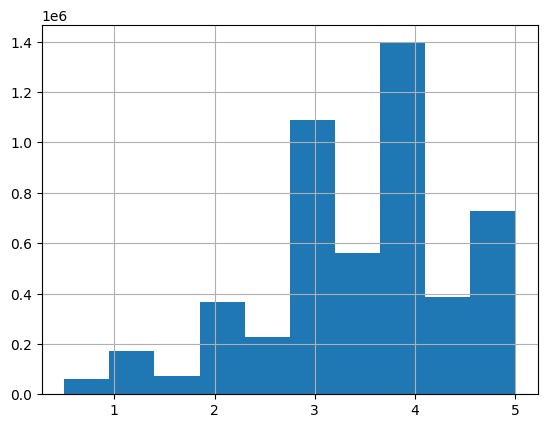

In [ ]:
print(movies.shape)
print(ratings.shape)

ratings['rating'].hist()

In [ ]:
pip install scikit-surprise

In [ ]:
from surprise import Dataset
from surprise import Reader
from surprise import SVD
from surprise.model_selection import train_test_split
from surprise import accuracy


In [ ]:


reader = Reader(rating_scale=(0.5,5))

data = Dataset.load_from_df(
    ratings_sample[['userId','movieId','rating']],
    reader
)

trainset, testset = train_test_split(data,test_size=0.2)

model = SVD()

model.fit(trainset)

predictions = model.test(testset)

print("RMSE:",accuracy.rmse(predictions))


RMSE: 0.9029
RMSE: 0.9029223760671805


In [ ]:
import pickle

with open("svd_model.pkl","wb") as f:
    pickle.dump(model,f)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

movies['genres'] = movies['genres'].str.replace('|',' ')

tfidf = TfidfVectorizer()

genre_matrix = tfidf.fit_transform(
    movies['genres']
)

In [ ]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy Romance
3,4,Waiting to Exhale (1995),Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy


In [ ]:
from sklearn.neighbors import NearestNeighbors
nn_model = NearestNeighbors(
    metric='cosine',
    algorithm='brute',
    n_neighbors=11
)

nn_model.fit(genre_matrix)

print("Nearest Neighbor Model Ready")

Nearest Neighbor Model Ready


In [ ]:
def recommend(movie_name):

    movie_index = movies[
        movies['title'] == movie_name
    ].index[0]

    distances, indices = nn_model.kneighbors(
        genre_matrix[movie_index]
    )

    recommendations = []

    for idx in indices.flatten()[1:]:

        recommendations.append(
            movies.iloc[idx]['title']
        )

    return recommendations

In [ ]:
recommend("Toy Story (1995)")

['Monsters, Inc. (2001)',
 'Aladdin (1992)',
 'Adventures of Rocky and Bullwinkle, The (2000)',
 'The Magic Crystal (2011)',
 'Asterix and the Vikings (Astérix et les Vikings) (2006)',
 "Emperor's New Groove, The (2000)",
 'Toy Story Toons: Small Fry (2011)',
 'Toy Story Toons: Hawaiian Vacation (2011)',
 'Turbo (2013)',
 'Wild, The (2006)']

In [ ]:
pickle.dump(
    nn_model,
    open("nn_model.pkl", "wb")
)


In [ ]:
pickle.dump(
    tfidf,
    open("tfidf.pkl","wb")
)

pickle.dump(
    movies,
    open("movies.pkl","wb")
)